In [43]:
import finesse
import matplotlib.pyplot as plt
import importlib
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
import functions
importlib.reload(functions)
from functions import *
finesse.configure(plotting=True)
from scipy.special import erf

In [44]:

def delta(B, xi):
    return 2 * B * np.sqrt(xi)

def kappa(xi, B):
    delta_val = delta(B, xi)
    
    # Handle division by zero for B=0 or xi=0 using np.where
    # According to the paper, kappa approaches 1 when delta approaches 0.
    kappa_val = np.where(
        delta_val == 0, 
        1.0, 
        (np.exp(-delta_val**2) - 1 + np.sqrt(np.pi) * delta_val * erf(delta_val)) / (delta_val**2) # FIXED: added **2 to exp
    )
    return kappa_val

def c1(B):
    return 0.876 - 18.8/(B+36.5) + 0.0166/(0.0693 + (B-0.44)**2) - 0.283/(0.931 + (B + 0.516)**3)

def c2(B):
    return 0.53 - 36/(B+95.1) + 0.0103/(0.332 + (B - 0.569)**2) - 0.497/(4.69 + (B + 1.15)**3)

def c3(B):
    return 0.796 - 0.506/(B + 0.378) + 0.0601/(0.421 + (B - 0.673)**2) + 0.0329/(0.0425 + (B- 0.221)**3)

def maximized_conversion_efficiency(xi, B):
    numerator = np.arctan(c1(B) * kappa(xi, B) * xi)
    denominator = c1(B) + c2(B) * xi * np.arctan(c3(B) * xi)
    return numerator / denominator

def cofocal_parameter(waist, wavenumber):
    return (waist**2) * wavenumber

def get_xi(waist, wavenumber, length):
    b = cofocal_parameter(waist, wavenumber)
    return length / b

# Equation 11: Calculates the optimal xi analytically
def optimal_xi(B):
    return 1.410 + 5.924 / ((B + 3.508)**2 - 1.762) + 0.7232 / ((B + 0.4640)**4 + 0.7577)


Refractive index at 1550 nm and 300 K: 1.816055
Optimal xi: 2.8713


C:\Users\eskil\AppData\Local\Temp\ipykernel_16088\1863927032.py:12: RuntimeWarning: invalid value encountered in divide
  (np.exp(-delta_val**2) - 1 + np.sqrt(np.pi) * delta_val * erf(delta_val)) / (delta_val**2) # FIXED: added **2 to exp
C:\Users\eskil\AppData\Local\Temp\ipykernel_16088\1863927032.py:12: RuntimeWarning: invalid value encountered in scalar divide
  (np.exp(-delta_val**2) - 1 + np.sqrt(np.pi) * delta_val * erf(delta_val)) / (delta_val**2) # FIXED: added **2 to exp


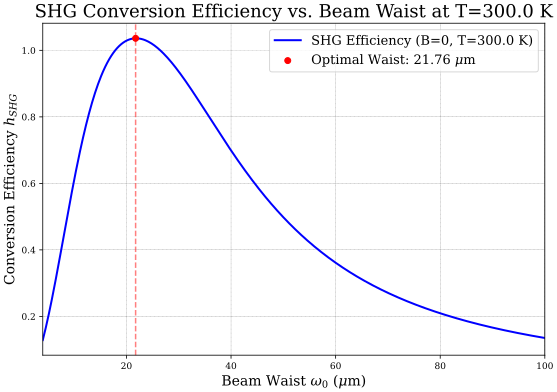

In [45]:
# temperature = np.linspace(273, 273+100, 200000)
#Plotting refractive index as a function of wavelength
#Parameters for the Sellmeier
A = 2.12725
B = 1.18431
C = 5.14852e-2
D = 0.6603
E = 100.00507
F = 9.68956e-3
#These experimental parameters are taken from "K. Fradkin, A. Arie, A. Skliar, and G. Rosenman"
wavelengths = np.array([1550])  # Wavelength in nm
temperature = np.array([300])  # Temperature in Kelvin
a1_list = np.array([9.9587, 9.9228, -8.9603, 4.1010])*1e-6  # Experimental values taken from S. Emanueli and A. Arie
a2_list = np.array([-1.1882 ,10.459, -9.8136, 3.1481])*1e-8  # Experimental values taken from S. Emanueli and A. Arie
n_refractive = refractive_index_total(temperature, A, B, C, D, E, F, a1_list, a2_list, wavelengths)
print(f"Refractive index at {wavelengths[0]} nm and {temperature[0]} K: {n_refractive[0]:.6f}")
# n_refractive = np.array([1])  # Ensure n_refractive is an array for broadcasting
a_z = 8.7e-6 #C^-1, Linear thermal expansion coefficient for KTP. Taken from Shai Emanueli and Ady Arie
Lambda_0 = 24.701e-6
L = 405*Lambda_0
length = crystal_length(L, temperature, 25+273.15, a_z)  # Example thermal expansion coefficient
# Setup your experimental parameters here (Using KTP crystal values from the paper as an example)
B_param = 0                # Walk-off parameter for KTP
wavelength = 1550e-9       # Fundamental wavelength in meters (1550 nm)

wavenumber = (2 * np.pi * n_refractive) / wavelength

# Create an array of beam waists from 4 um to 100 um
waists = np.linspace(4e-6, 100e-6, 500)

# Calculate xi and SHG efficiency for each waist
# Use broadcasting to calculate for all temperatures and waists: (N_temps, 1) / (1, N_waists) -> (N_temps, N_waists)
xi_vals = get_xi(waists[None, :], wavenumber[:, None], length[:, None])
efficiency = maximized_conversion_efficiency(xi_vals, B_param)

# Find the exact mathematical optimum using Eq 11
xi_opt = optimal_xi(B_param)
waist_opt = np.sqrt(length / (wavenumber * xi_opt))
eff_opt = maximized_conversion_efficiency(xi_opt, B_param)
print(f"Optimal xi: {xi_opt:.4f}")
# --- 3. CREATE THE PLOT ---

# Select an index to plot (e.g., middle of the temperature range)
plot_idx = [len(temperature) // 2] 
fig, ax = plt.subplots(figsize=(9, 6))
for i in plot_idx:
    current_temp = temperature[i]
    current_eff = efficiency[i]
    current_waist_opt = waist_opt[i]
    ax.plot(waists * 1e6, current_eff, label=f'SHG Efficiency (B={B_param}, T={current_temp:.1f} K)', lw=2)

    # Mark the optimal waist for the selected temperature
    ax.scatter(current_waist_opt * 1e6, eff_opt, color='red', zorder=5, 
                label=f'Optimal Waist: {current_waist_opt * 1e6:.2f} $\mu$m')
    ax.axvline(current_waist_opt * 1e6, color='red', linestyle='--', alpha=0.5)

ax.set_title(f'SHG Conversion Efficiency vs. Beam Waist at T={current_temp:.1f} K', fontsize=18)
ax.set_xlabel('Beam Waist $\omega_0$ ($\mu$m)', fontsize=14)
ax.set_ylabel('Conversion Efficiency $h_{SHG}$', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=13)
path = f'C:\\Users\\eskil\\OneDrive\\DTU\\6.sem\\bachelor_project\\figures\\shg_efficiency_vs_waist.png'
plt.savefig(path, dpi=500, bbox_inches='tight')
plt.show()

In [46]:
print(n_refractive)

[1.8160549]


In [47]:
def reyleigh_from_waist(w0, wavelength, n):
    return np.pi * (w0**2) * n / wavelength
rayleigh_range = reyleigh_from_waist(waist_opt, wavelength, n_refractive)
print(f"Rayleigh Range for Optimal Waist: {rayleigh_range[0]*1e3:.2f} mm")

Rayleigh Range for Optimal Waist: 1.74 mm


In [48]:
#ABCD matrix for the double pass of the crystal. We model the reflection on the curved back of the crystal as a thick lens
#Propagation from crystal start to crystal end:
matrix_propagation = np.array([[1, np.mean(length)], [0, 1]])
#Reflection on the curved back of the crystal:
rof = 10e-3 # Example radius of curvature for the back surface 10 mm
matrix_reflection = np.array([[1,0], [-2/rof, 1]])
matrix_propagation_2 = np.array([[1, np.mean(length)], [0, 1]])
ABCD = matrix_propagation_2 @ matrix_reflection @ matrix_propagation
print("ABCD Matrix for Double Pass:")
print(ABCD)
A = ABCD[0,0]
B = ABCD[0,1]
C = ABCD[1,0]
D = ABCD[1,1]
z_0 = 5e-3 # Waist position
q1 = -length[0]/2 + 1j * 1.74e-3 # Example input beam parameter (waist at the front surface) 1.74 mm is the Rayleigh range for the optimal waist
q2 = (A*q1 + B) / (C*q1 + D)
print(f"Output beam parameter after double pass: {q2}")
z_R2 = np.imag(q2) # Rayleigh range after double pass
print(f"Rayleigh Range after double pass: {z_R2*1e3:.2f} mm")
z2 = 10e-3
z_02 = -np.real(q2) + 10e-3 # Waist position after double pass. Re(q2) = z_2 - z_02 => z_02 = z_2 - Re(q2)
print(f"Waist position after double pass: {z_02*1e3:.2f} mm")
def waist_from_rayleigh(z_R, wavelength, n):
    return np.sqrt((z_R * wavelength) / (np.pi * n))
waist2 = waist_from_rayleigh(z_R2, wavelength, n_refractive)
print(f"Waist size after double pass: {waist2[0]*1e6:.2f} um")


ABCD Matrix for Double Pass:
[[-1.00081320e+00 -8.13533219e-06]
 [-2.00000000e+02 -1.00081320e+00]]
Output beam parameter after double pass: (0.00498727875850643+0.01436779647781842j)
Rayleigh Range after double pass: 14.37 mm
Waist position after double pass: 5.01 mm
Waist size after double pass: 62.48 um


Running optimization (this takes ~3 seconds)...

--- OPTIMAL COMPROMISE FOUND ---
Input Beam Waist:      36.9 µm
Input Waist Position:  5.00 mm from front face
Forward Efficiency h1: 0.780
Backward Efficiency h2:0.781
Total Efficiency sum:  1.560
q_1 = 5.00e-03+5.01e-03j m
q_2 = 3.01e-03+1.00e-03j m


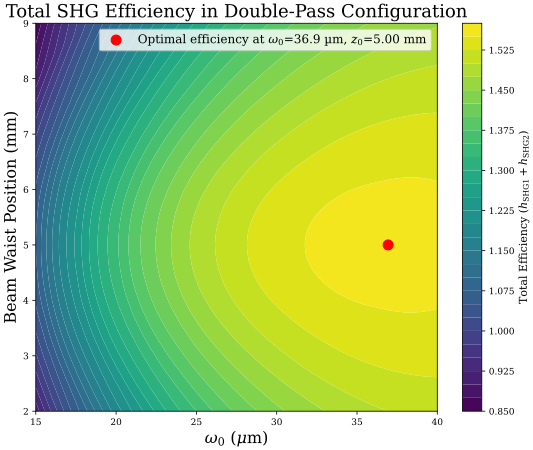

In [49]:
# --- 1. SOLVING THE EXACT BOYD-KLEINMAN INTEGRAL ---
def bk_efficiency_off_center(xi, mu):
    """
    Solves the exact Boyd-Kleinman integral for B=0 and arbitrary focal position mu.
    mu = (L - 2z_0) / L. (mu=0 is center, mu=1 is front face, mu=-1 is back face)
    """
    if xi < 1e-4: return xi # Near-field approximation
    
    # Integration bounds from the 1968 paper
    tau = np.linspace(-xi * (1 + mu), xi * (1 - mu), 300)
    dtau = tau[1] - tau[0]
    
    # Sweep over phase-matching parameter sigma to find the optimum
    sigmas = np.linspace(-3, 5, 100)
    phase = sigmas[:, None] * tau[None, :]
    
    # Boyd-Kleinman integrand: exp(i*sigma*tau) / (1 + i*tau)
    integrand = np.exp(1j * phase) / (1 + 1j * tau[None, :])
    integral = np.sum(integrand, axis=1) * dtau
    
    # Calculate efficiency h and return the maximum found over all sigmas
    h_vals = np.abs(integral)**2 / (4 * xi)
    return np.max(h_vals)

# --- 2. DOUBLE-PASS ABCD SIMULATION ---
def simulate_double_pass(waist, z01, L, wavelength, n, R_mirror):
    # 1st Pass (Forward)
    zR1 = np.pi * (waist**2) * n / wavelength
    xi1 = L / (2 * zR1)
    mu1 = (L - 2 * z01) / L
    h1 = bk_efficiency_off_center(xi1, mu1)
    
    # ABCD Transformation off the back mirror
    d_in = L - z01
    q_in = d_in + 1j * zR1
    # Reflection: 1/q_out = 1/q_in - 2/R
    q_out = 1 / ((1 / q_in) - (2 / R_mirror))
    
    # 2nd Pass (Backward)
    zR2 = np.imag(q_out)
    z02 = L + np.real(q_out) # New waist position relative to front face
    
    xi2 = L / (2 * zR2)
    # Because it propagates backwards, the focal position geometry flips
    mu2 = (L - 2 * z02) / L 
    h2 = bk_efficiency_off_center(xi2, mu2)
    
    return h1, h2, h1 + h2

# --- 3. GRID SEARCH OPTIMIZATION ---
L = 10e-3               # 10 mm crystal
wavelength = 1550e-9    # 1550 nm pump
n_ref = 1.81            # Refractive index
R_mirror = 10e-3        # 10 mm ROC back mirror

# Sweep parameters
waists = np.linspace(15e-6, 40e-6, 50)  # 15 to 40 um
z0s = np.linspace(2e-3, 9e-3, 50)       # Waist pos from 2mm to 9mm

H_total = np.zeros((len(z0s), len(waists)))

max_h = 0
best_w = 0
best_z0 = 0
best_h1, best_h2 = 0, 0

print("Running optimization (this takes ~3 seconds)...")
for i, z0 in enumerate(z0s):
    for j, w in enumerate(waists):
        h1, h2, h_tot = simulate_double_pass(w, z0, L, wavelength, n_ref, R_mirror)
        H_total[i, j] = h_tot
        
        if h_tot > max_h:
            max_h = h_tot
            best_w = w
            best_z0 = z0
            best_h1, best_h2 = h1, h2

print(f"\n--- OPTIMAL COMPROMISE FOUND ---")
print(f"Input Beam Waist:      {best_w*1e6:.1f} µm")
print(f"Input Waist Position:  {best_z0*1e3:.2f} mm from front face")
print(f"Forward Efficiency h1: {best_h1:.3f}")
print(f"Backward Efficiency h2:{best_h2:.3f}")
print(f"Total Efficiency sum:  {max_h:.3f}")
print(f"q_1 = {best_z0 + 1j * (np.pi * best_w**2 * n_ref / wavelength):.2e} m")
print(f"q_2 = {((ABCD[0,0]*(best_z0 + 1j * (np.pi * best_w**2 * n_ref / wavelength)) + ABCD[0,1]) / (ABCD[1,0]*(best_z0 + 1j * (np.pi * best_w**2 * n_ref / wavelength)) + ABCD[1,1])):.2e} m")

# --- 4. PLOTTING THE HEATMAP ---           
W, Z = np.meshgrid(waists * 1e6, z0s * 1e3)
plt.figure(figsize=(9, 7))
cp = plt.contourf(W, Z, H_total, levels=30, cmap='viridis')
plt.colorbar(cp, label='Total Efficiency $(h_{\mathrm{SHG}1} + h_{\mathrm{SHG}2})$')
plt.scatter(best_w * 1e6, best_z0 * 1e3, color='red', marker='o', s=100, label=f'Optimal efficiency at $\omega_0$={best_w*1e6:.1f} µm, $z_0$={best_z0*1e3:.2f} mm')

plt.title('Total SHG Efficiency in Double-Pass Configuration', fontsize=18)
plt.xlabel('$\omega_0$ ($\mu$m)', fontsize=16)
plt.ylabel('Beam Waist Position (mm)', fontsize=16)
plt.legend(fontsize=12)
path = f'C:\\Users\\eskil\\OneDrive\\DTU\\6.sem\\bachelor_project\\figures\\optimal_waist.png'
plt.savefig(path, dpi=500, bbox_inches='tight')
plt.show()

In [50]:
#Cavity case where q_in = q_out after double pass. This means the beam reproduces itself after one round trip in the cavity, which is a common design goal for stable cavities.
# --- 5. CHECKING CAVITY SELF-REPRODUCTION CONDITION ---
if np.isclose(q2, q1, atol=1e-6):
    print("\nThe cavity is self-reproducing (q_out ≈ q_in).")
    opt_z0_crystal = best_z0
    target_z0_crystal = L / 2  # Targeting the waist at the center of the crystal
    print(f"Target Waist:      {waist_opt[0]*1e6:.2f} µm")

In [56]:
import scipy.optimize as opt
import numpy as np

# --- Final part ---
# Finding lens focal lengths/distances in 3 lens configuration for optimal waist and position.
print("\n--- OPTIMIZING LENS SYSTEM ---")
print(best_w, best_z0)
# Target parameters from your previous grid search
target_w = best_w           # The optimal waist size inside the crystal
target_z0_crystal = best_z0 # The optimal waist position inside the crystal

# The apparent waist position in air (due to refraction at the crystal surface)
target_z0_air = target_z0_crystal / n_ref

# Initial beam parameter (Convert mm to meters!)
q_grinlaser = (-25.56 + 1j * 64.36) * 1e-3 

# Lens and system parameters
n2 = 1.444 # Index for 1550 nm
n1 = 1.0   # Air
tot_length = 350e-3 # Total length from laser to crystal (350 mm)

# Thicknesses
t1 = 6e-3 
t2 = 4e-3 
t_mirror = 8.6e-3 

# Radii of curvature (using your defined variables)
Rof_lens1 = 25e-3 
Rof_lens2 = -25e-3 
Rof_in_mirror = np.inf # Flat mirror for simplicity
Rof_out_mirror = 15.5e-3 # Example ROC for the curved mirror

# Position constraints for the first two lenses
min_lens1_pos = 5e-3    # Minimum 5 mm
max_lens1_pos = 150e-3  # Maximum 150 mm (15 cm)
max_lens2_pos = 150e-3  # Maximum 150 mm (15 cm)

def thick_lens_ABCD(R1, R2, t, n_lens, n_air=1.0):
    """Generates a physically correct ABCD matrix for a thick lens."""
    # Surface 1: Air -> Lens
    C1 = 0 if np.isinf(R1) else (n_air - n_lens) / (R1 * n_lens)
    M1 = np.array([[1, 0],[C1, n_air / n_lens]])
    
    # Propagation through Lens
    M2 = np.array([[1, t], [0, 1]])
    
    # Surface 2: Lens -> Air
    C2 = 0 if np.isinf(R2) else (n_lens - n_air) / (R2 * n_air)
    M3 = np.array([[1, 0], [C2, n_lens / n_air]])
    
    return M3 @ M2 @ M1

# Create standard thick lens matrices
# Based on your code, Lens 1 & 2 have a flat first surface (R1=inf) and a curved second surface
M_lens1 = thick_lens_ABCD(np.inf, Rof_lens1, t1, n2, n1)
M_lens2 = thick_lens_ABCD(np.inf, Rof_lens2, t2, n2, n1)
M_lens3 = thick_lens_ABCD(Rof_in_mirror, Rof_out_mirror, t_mirror, n2, n1)

def evaluate_system(d0, d1, d2):
    """Multiplies ABCD matrices for a given set of distances."""
    d3 = tot_length - d0 - d1 - d2 - t1 - t2 - t_mirror
    
    prop_d0 = np.array([[1, d0],[0, 1]])
    prop_d1 = np.array([[1, d1],[0, 1]])
    prop_d2 = np.array([[1, d2], [0, 1]])
    prop_d3 = np.array([[1, d3], [0, 1]])
    
    # Total ABCD matrix (Multiply from right to left!)
    ABCD = prop_d3 @ M_lens3 @ prop_d2 @ M_lens2 @ prop_d1 @ M_lens1 @ prop_d0
    
    A, B = ABCD[0, 0], ABCD[0, 1]
    C, D = ABCD[1, 0], ABCD[1, 1]
    
    # Output beam parameter just before hitting the crystal
    q_out = (A * q_grinlaser + B) / (C * q_grinlaser + D)
    
    z_R_out = np.imag(q_out)
    w_out = np.sqrt(abs(z_R_out) * wavelength / np.pi)
    z0_out_air = -np.real(q_out)
    
    return w_out, z0_out_air, d3

def cost_function(x):
    """Cost function for the optimizer to minimize."""
    d0, d1, d2 = x
    
    w_out, z0_out_air, d3 = evaluate_system(d0, d1, d2)
    
    # Calculate the relative squared error for waist size and waist position
    error_w = ((w_out - target_w) / target_w) ** 2
    error_z0 = ((z0_out_air - target_z0_air) / target_z0_air) ** 2
    
    # Soft penalties instead of hard "return 1e6" to give the optimizer a smooth gradient
    penalty = 0
    
    # Penalty for violating clearance to crystal
    min_d3 = 15e-3
    if d3 < min_d3:
        penalty += 1e5 * ((min_d3 - d3) / min_d3)**2
        
    # Penalty for violating position constraint of lens 1 (d0) and lens 2
    pos_lens1 = d0
    pos_lens2 = d0 + t1 + d1
    
    # Very heavily penalize violating the max_lens1 and max_lens2 constraints
    if pos_lens1 < min_lens1_pos:
        penalty += 1e5 * ((min_lens1_pos - pos_lens1) / min_lens1_pos)**2
    if pos_lens1 > max_lens1_pos:
        penalty += 1e5 * ((pos_lens1 - max_lens1_pos) / max_lens1_pos)**2
    if pos_lens2 > max_lens2_pos:
        penalty += 1e5 * ((pos_lens2 - max_lens2_pos) / max_lens2_pos)**2
        
    return error_w + error_z0 + penalty

# Run differential evolution with wider bounds, letting the soft penalties do the work
print("Finding optimal lens layout... bounds relaxed to allow solving (soft penalties active)")
bounds = [(1e-3, 300e-3), (1e-3, 300e-3), (1e-3, 300e-3)]
result = opt.differential_evolution(cost_function, bounds, strategy='best1bin', popsize=40, tol=1e-6)

if result.success:
    opt_d0, opt_d1, opt_d2 = result.x
    opt_w, opt_z0_air, opt_d3 = evaluate_system(opt_d0, opt_d1, opt_d2)
    
    # Convert apparent air position back to real position inside crystal
    opt_z0_crystal = opt_z0_air * n_ref 
    
    print("\n--- 3-LENS OPTIMIZATION SUCCESSFUL ---")
    print("Required Distances:")
    print(f"d0 (Laser to Lens 1):   {opt_d0*1e3:>6.2f} mm")
    print(f"d1 (Lens 1 to Lens 2):  {opt_d1*1e3:>6.2f} mm")
    print(f"d2 (Lens 2 to Lens 3):  {opt_d2*1e3:>6.2f} mm")
    print(f"d3 (Lens 3 to Crystal): {opt_d3*1e3:>6.2f} mm")
    
    total_physical_dist = opt_d0 + opt_d1 + opt_d2 + opt_d3 + t1 + t2 + t_mirror
    print(f"\nTotal System Length check: {total_physical_dist*1e3:.2f} mm")
    
    print("\nFinal Achieved Beam Parameters:")
    print(f"Target Waist:       {target_w*1e6:.2f} µm")
    print(f"Achieved Waist:     {opt_w*1e6:.2f} µm")
    print(f"Target Position:    {target_z0_crystal*1e3:.2f} mm inside crystal")
    print(f"Achieved Position:  {opt_z0_crystal*1e3:.2f} mm inside crystal")
else:
    print("Optimization failed to converge. Consider widening bounds or checking target constraints.")


--- OPTIMIZING LENS SYSTEM ---
3.6938775510204086e-05 0.004999999999999999
Finding optimal lens layout... bounds relaxed to allow solving (soft penalties active)

--- 3-LENS OPTIMIZATION SUCCESSFUL ---
Required Distances:
d0 (Laser to Lens 1):    99.32 mm
d1 (Lens 1 to Lens 2):   44.96 mm
d2 (Lens 2 to Lens 3):  172.13 mm
d3 (Lens 3 to Crystal):  14.99 mm

Total System Length check: 350.00 mm

Final Achieved Beam Parameters:
Target Waist:       36.94 µm
Achieved Waist:     68.24 µm
Target Position:    5.00 mm inside crystal
Achieved Position:  -60.86 mm inside crystal


In [52]:
#position of the lenses alon the 350mm system
pos_lens1 = opt_d0
pos_lens2 = pos_lens1 + t1 + opt_d1
pos_lens3 = pos_lens2 + t2 + opt_d2
print("\n--- FINAL LENS POSITIONS ---")
print(f"Lens 1 position: {pos_lens1*1e3:.2f} mm from laser")
print(f"Lens 2 position: {pos_lens2*1e3:.2f} mm from laser")
print(f"Lens 3 position: {pos_lens3*1e3:.2f} mm from laser")
print(f"With radius of curvature: {Rof_lens1*1e3:.2f} mm, {Rof_lens2*1e3:.2f} mm, {Rof_in_mirror*1e3:.2f} mm (in), {Rof_out_mirror*1e3:.2f} mm (out)")
print(f"ABCD Matrix for the system:")
print(ABCD)


--- FINAL LENS POSITIONS ---
Lens 1 position: 99.32 mm from laser
Lens 2 position: 150.28 mm from laser
Lens 3 position: 326.41 mm from laser
With radius of curvature: 25.00 mm, -25.00 mm, inf mm (in), 15.50 mm (out)
ABCD Matrix for the system:
[[-1.00081320e+00 -8.13533219e-06]
 [-2.00000000e+02 -1.00081320e+00]]
